In [2]:
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
from tqdm import tqdm

In [48]:
mechanisms = ['MCAR', 'MAR_l', 'MAR_h', 'MNAR_l', 'MNAR_h']
mr_values = ["05", "10", "15", "20", "25"]
n = 5

In [80]:
class plotter:

    patient_metrics_df = None
    patients = []

    def __init__(self, metric):
        self.metric = metric
        self.pmetrics_df()

    def _intervals_overlap(self, a, b):
        """Verifica se os intervalos a e b se sobrepõem"""
        return max(a[0], b[0]) <= min(a[1], b[1])

    def _match_event_intervals(self, y_true, y_pred):
        """
        Compara listas de intervalos (eventos reais e previstos).
        Cada intervalo é uma tupla: (inicio, fim)

        Retorna TP, FP, FN
        """
        matched = set()

        for i, pred in enumerate(y_pred):
            for j, true in enumerate(y_true):
                if self._intervals_overlap(pred, true):
                    matched.add(j)
                    break  # conta só uma correspondência

        TP = len(matched)
        FP = len(y_pred) - TP
        FN = len(y_true) - TP

        return TP, FP, FN

    def pmetrics_df(self):
        
        self.patients = [patient for patient in os.listdir(f"Patients/{self.metric}") if os.path.isdir(os.path.join(f"Patients/{self.metric}", patient))]
        patient_metrics = {}

        failed = []
        for patient in self.patients:
            try:
                df_full = pd.read_csv(f'Patients/{self.metric}/{patient}/Anomalies/{patient}_original_anomalies.csv', usecols=[1, 2], header=None)
            except (FileNotFoundError, pd.errors.EmptyDataError):
                failed.append(patient)
                continue

            metrics_by_mec = {}
            for mec in mechanisms:
                metrics_by_mr = []
                for mr in mr_values:
                    tp_sum = fp_sum = fn_sum = 0
                    count = 0
                    for i in range(1, n + 1):
                        file_path = f'Patients/{self.metric}/{patient}/Anomalies/{mec}/{i}/{patient}_anomalies_{mec}_{i}_{mr}.csv'
                        if not os.path.exists(file_path) or os.path.getsize(file_path) == 0:
                            continue
                        try:
                            df_miss = pd.read_csv(file_path, usecols=[1, 2], header=None)
                        except pd.errors.EmptyDataError:
                            continue

                        y_true_intervals = [(pd.to_datetime(start), pd.to_datetime(start)) for start in df_full[1]]
                        y_pred_intervals = [(pd.to_datetime(start), pd.to_datetime(start)) for start in df_miss[1]]

                        TP, FP, FN = self._match_event_intervals(y_true_intervals, y_pred_intervals)
                        tp_sum += TP
                        fp_sum += FP
                        fn_sum += FN
                        count += 1

                    if count > 0:
                        accuracy = tp_sum / (tp_sum + fp_sum + fn_sum) if (tp_sum + fp_sum + fn_sum) > 0 else 0
                        precision = tp_sum / (tp_sum + fp_sum) if (tp_sum + fp_sum) > 0 else 0
                        recall = tp_sum / (tp_sum + fn_sum) if (tp_sum + fn_sum) > 0 else 0
                        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
                    else:
                        accuracy = precision = recall = f1 = 0

                    metrics_by_mr.append({
                        'MR': mr,
                        'Accuracy': accuracy * 100,
                        'Precision': precision * 100,
                        'Recall': recall * 100,
                        'F1_Score': f1 * 100
                    })
                metrics_by_mec[mec] = pd.DataFrame(metrics_by_mr)
            patient_metrics[patient] = metrics_by_mec

        for patient in failed:
            self.patients.remove(patient)

        records = []
        for patient, mec_dict in patient_metrics.items():
            for mec, df in mec_dict.items():
                for _, row in df.iterrows():
                    records.append({
                        'Patient': patient,
                        'MEC': mec,
                        'MR': row['MR'],
                        'Accuracy': row['Accuracy'],
                        'Precision': row['Precision'],
                        'Recall': row['Recall'],
                        'F1_Score': row['F1_Score']
                    })
        self.patient_metrics_df = pd.DataFrame(records)

    def plot_heatmap(self, metric):

        # Troca o eixo: MR no índice, MEC nas colunas
        self.patient_metrics_df['MR'] = pd.Categorical(self.patient_metrics_df['MR'], categories=mr_values, ordered=True)
        heatmap_data = {}
        for mec in mechanisms:
            df_pivot = self.patient_metrics_df[self.patient_metrics_df['MEC'] == mec].pivot(index='MR', columns='Patient', values=metric)
            df_pivot = df_pivot.loc[mr_values, self.patients]
            heatmap_data[mec] = df_pivot

        fig, axes = plt.subplots(len(mechanisms), 1, figsize=(18, 10), sharex=True, sharey=True, gridspec_kw={'hspace': 0.3})

        vmin = min(df.min().min() for df in heatmap_data.values())
        vmax = max(df.max().max() for df in heatmap_data.values())

        for ax, (mec, df) in zip(axes, heatmap_data.items()):
            sns.heatmap(df, ax=ax, cmap='RdYlBu', vmin=vmin, vmax=vmax, cbar=False, annot=True, fmt=".1f")
            ax.set_title(f'{mec}', fontsize=12)
            ax.set_ylabel('')
            if ax == axes[2]:
                ax.set_ylabel('Missing Rate (%)', fontsize=12)
            ax.set_xlabel('')
            if ax == axes[-1]:
                ax.set_xlabel('Patients', fontsize=12)
            ax.set_yticklabels(df.index, rotation=0)
            ax.set_xticklabels(df.columns, rotation=90, fontsize=9)

        cbar = fig.colorbar(
            axes[0].collections[0],
            ax=axes,
            orientation='vertical',
            fraction=0.025,
            pad=0.02,
            aspect=30
        )
        cbar.set_label(f'{metric} (%)', fontsize=12)
        plt.savefig(f'Plots/Heatmaps/Heatmap_{self.metric}_{metric}.png', dpi=300, bbox_inches='tight')
    
    
    def plot_pheatmap(self, patient = 'AIFDJZB'):
        patient_spec = self.patient_metrics_df[self.patient_metrics_df['Patient'] == patient]
        metrics = ['Accuracy', 'Precision', 'Recall', 'F1_Score']
        fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharey=True)
        plt.subplots_adjust(wspace=0.1, hspace=0.4)

        for idx, metric in enumerate(metrics):
            ax = axes[idx // 2, idx % 2]
            patient_pivot = patient_spec.pivot(index='MEC', columns='MR', values=metric)
            sns.heatmap(patient_pivot, cmap='RdYlBu', cbar=False, annot=True, fmt=".1f", vmin=0, vmax=100, ax=ax, cbar_kws={'label': f'{metric} (%)'} if idx == 3 else None)
            ax.set_title(metric)
            ax.set_xlabel('Missing Rate (%)')

        for ax in axes.flat:
            ax.set_ylabel('')

        cbar = fig.colorbar(
            axes[0, 0].collections[0],
            ax=axes,
            orientation='vertical',
            fraction=0.025,
            pad=0.02,
            aspect=30,
            label='Percentage (%)'
        )

        plt.savefig(f'Plots/Heatmaps/Heatmap_{self.metric}_{patient}.png', bbox_inches='tight', dpi=300)
        

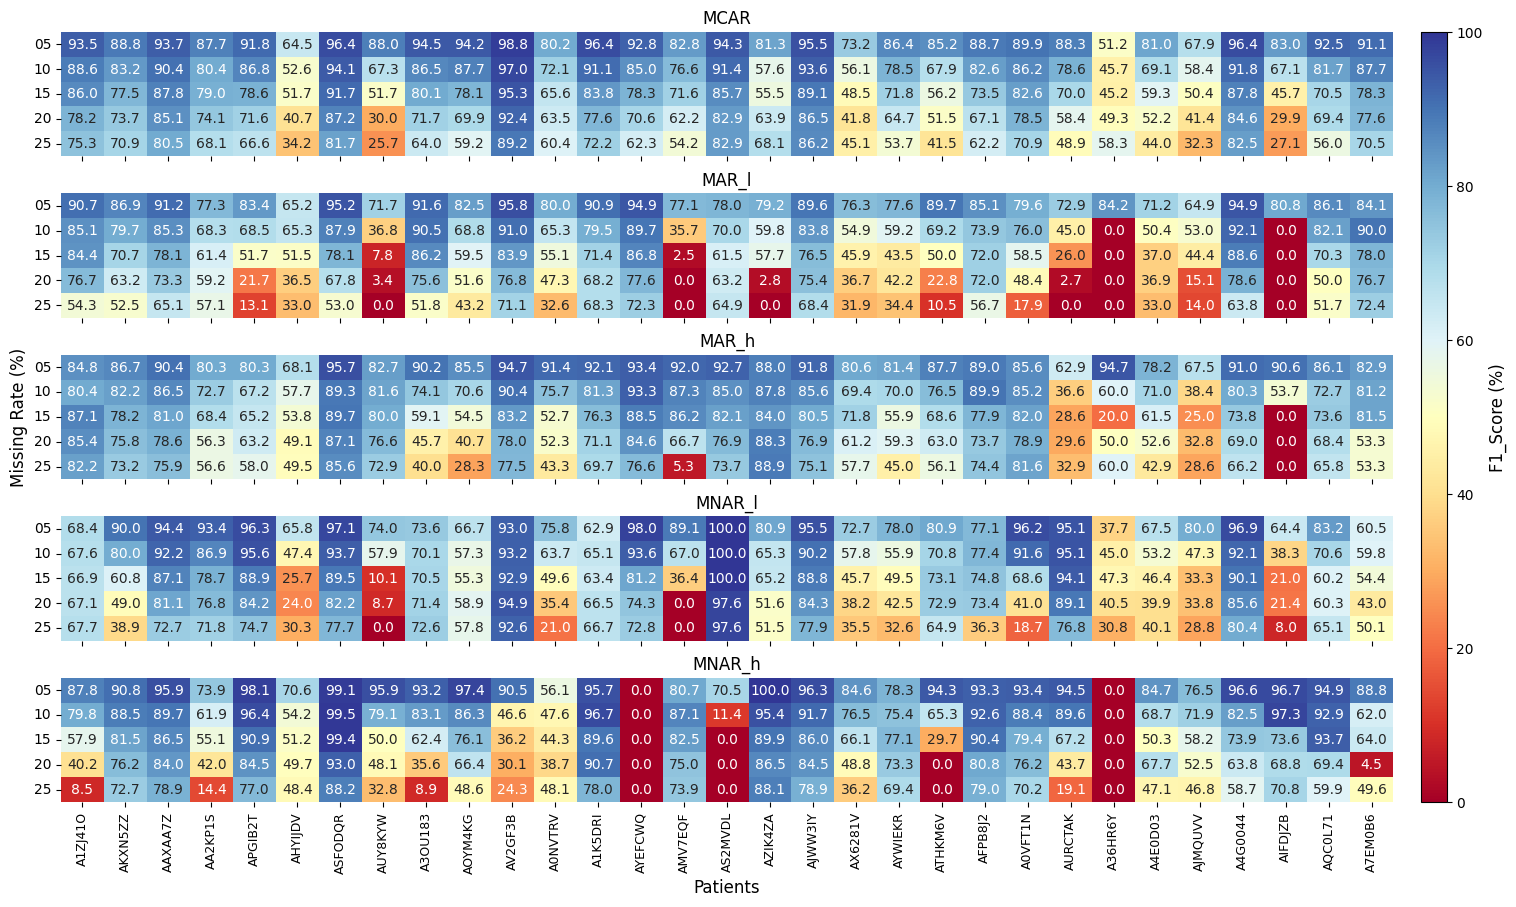

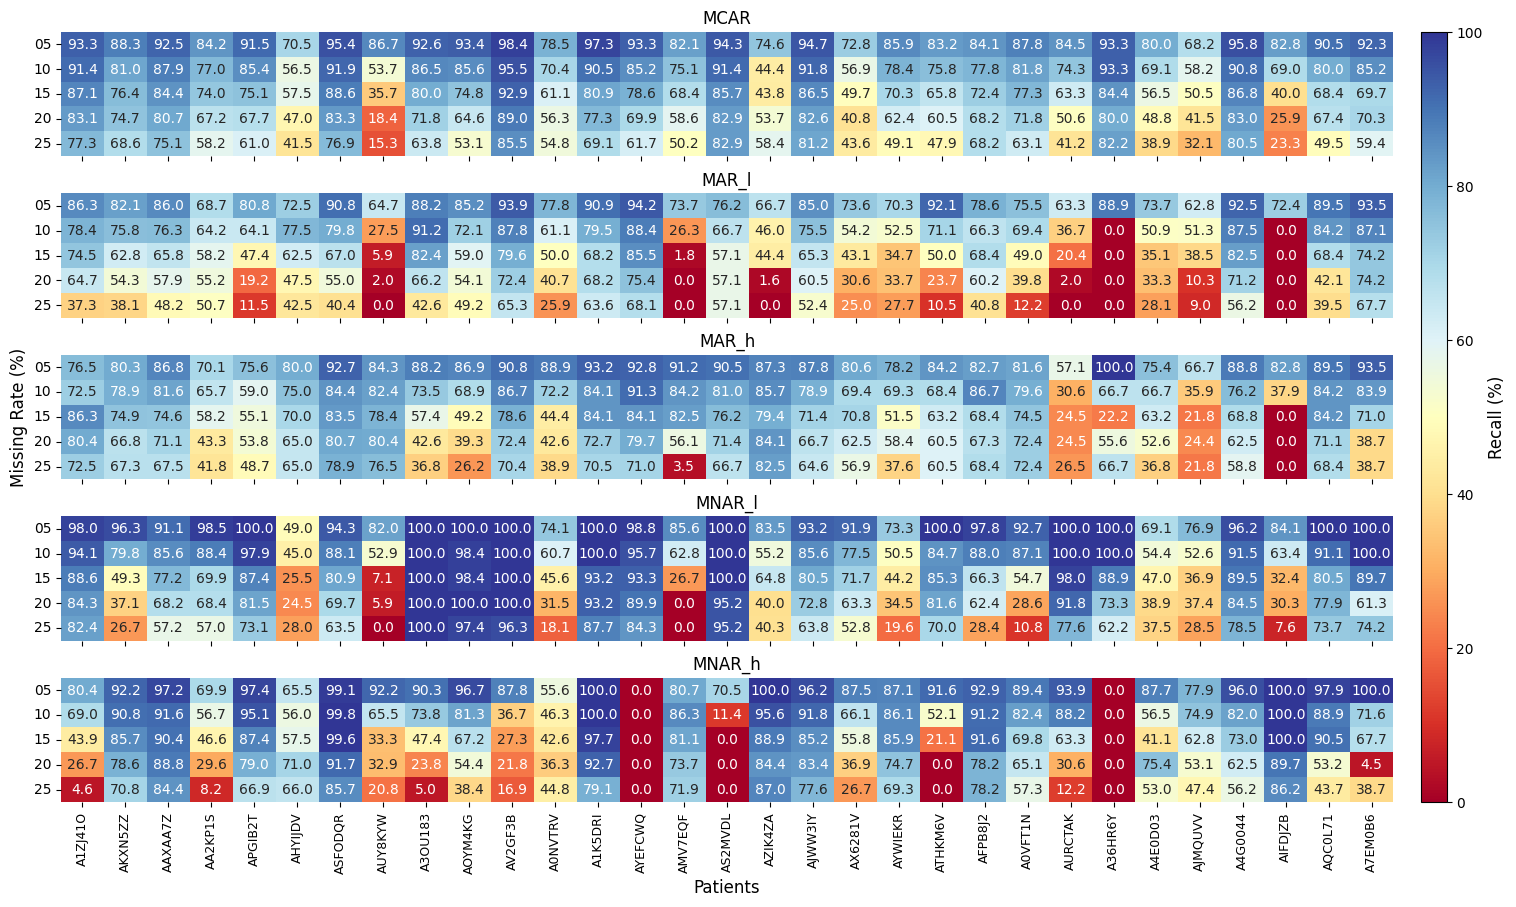

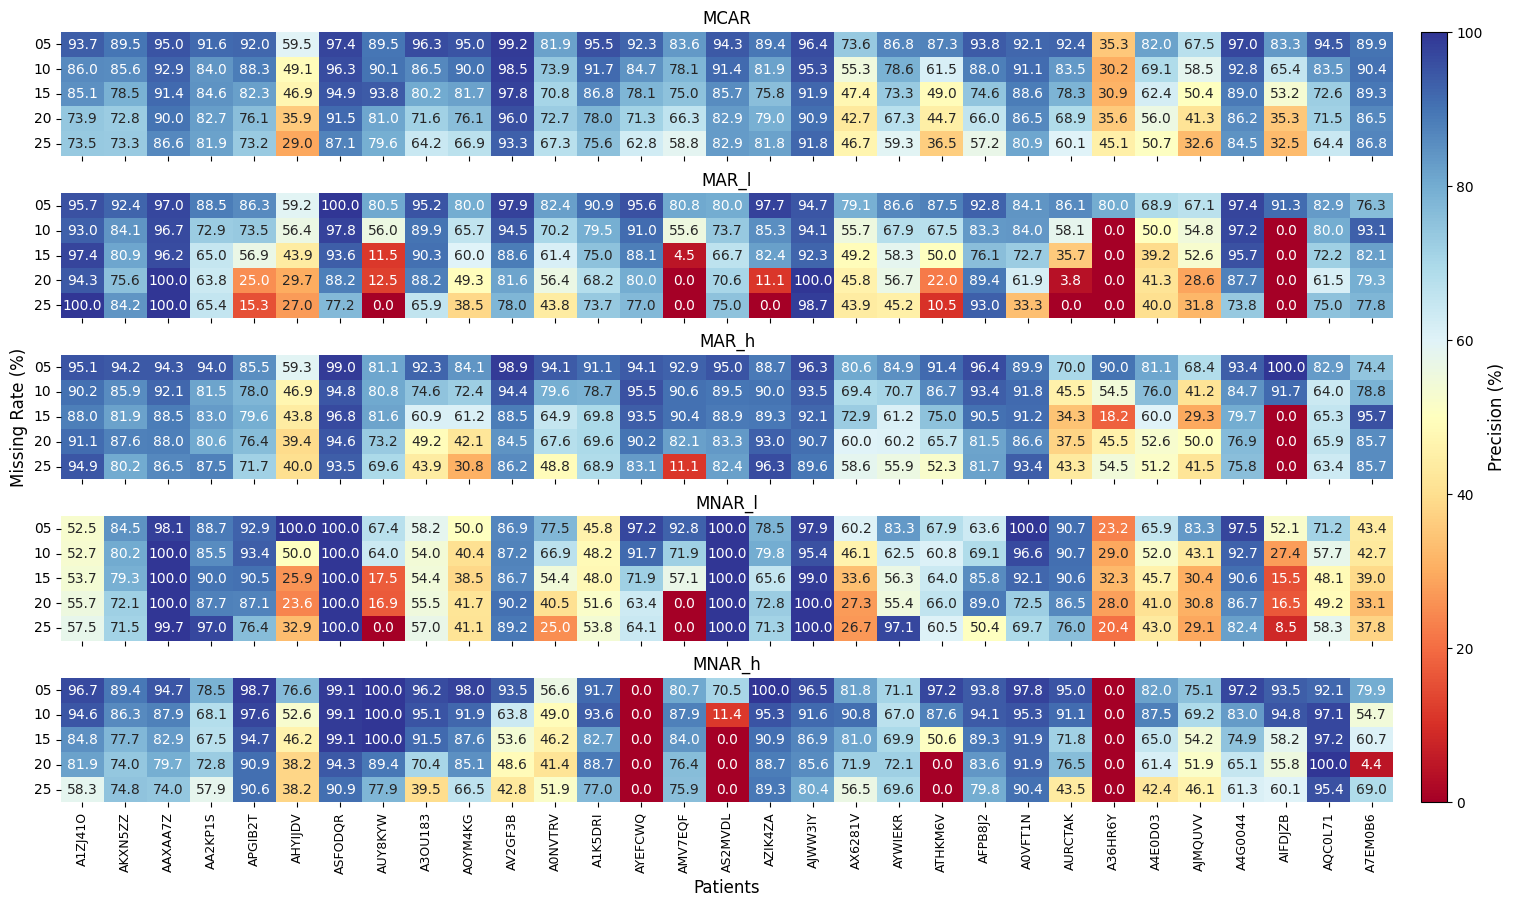

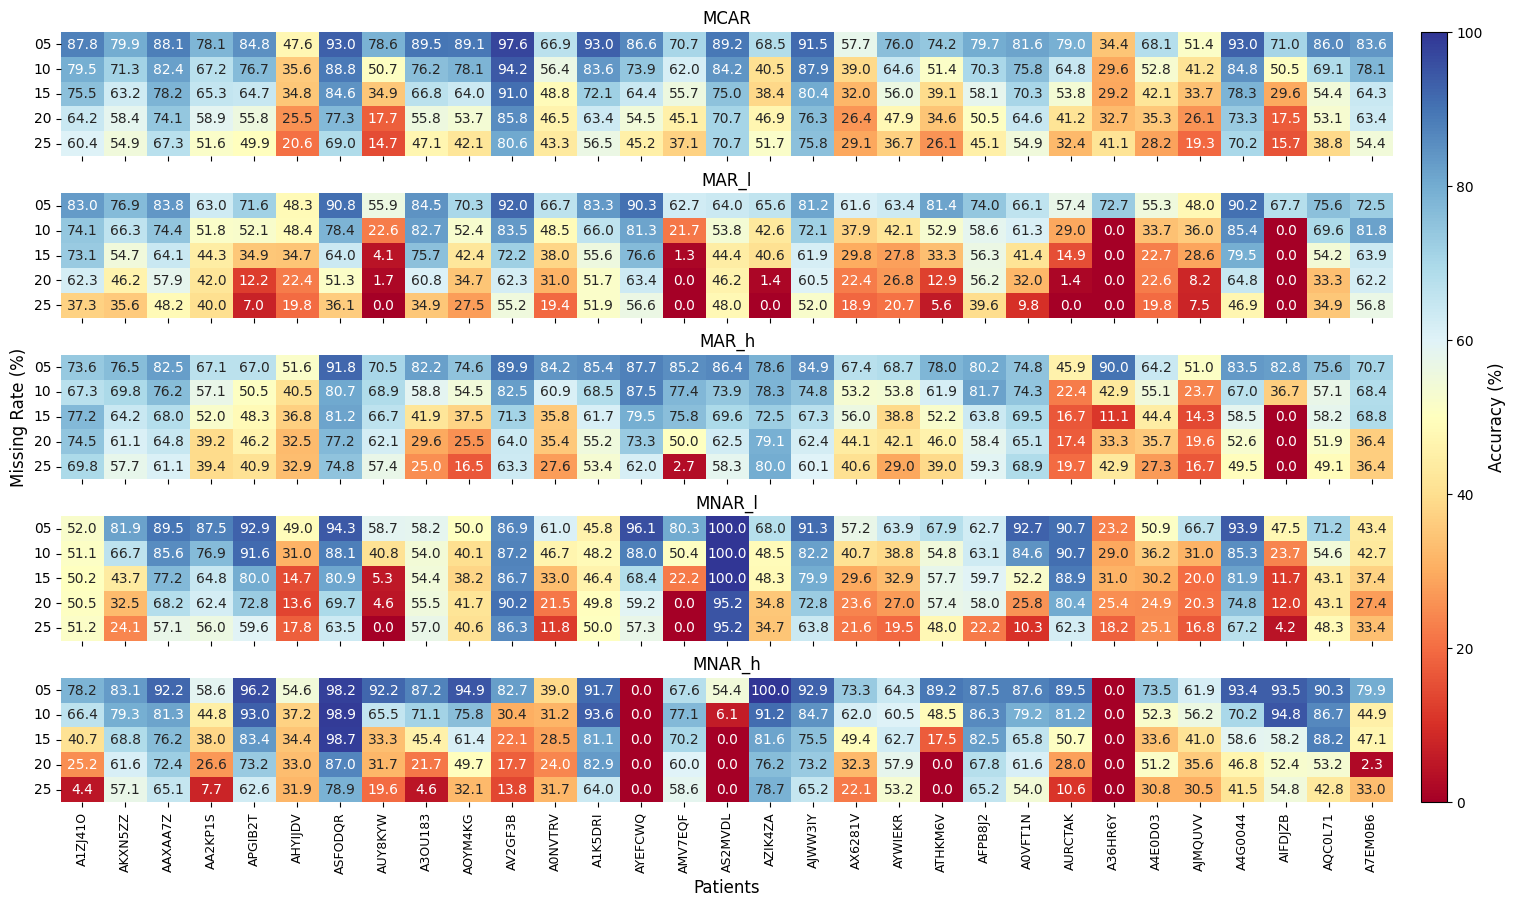

In [74]:
results_rhr = plotter("RHR")
results_rhr.plot_heatmap("F1_Score")
results_rhr.plot_heatmap("Recall")
results_rhr.plot_heatmap("Precision")
results_rhr.plot_heatmap("Accuracy")


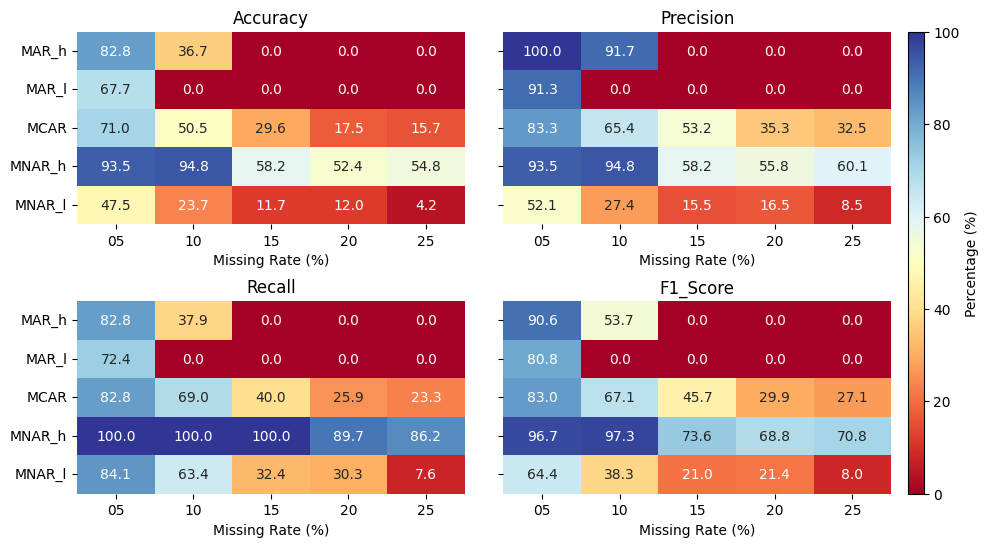

In [81]:
results_rhr = plotter("RHR")
results_rhr.plot_pheatmap()

In [68]:
results_hros = plotter("HROS")


AttributeError: 'plotter' object has no attribute 'plot_pheatmap'

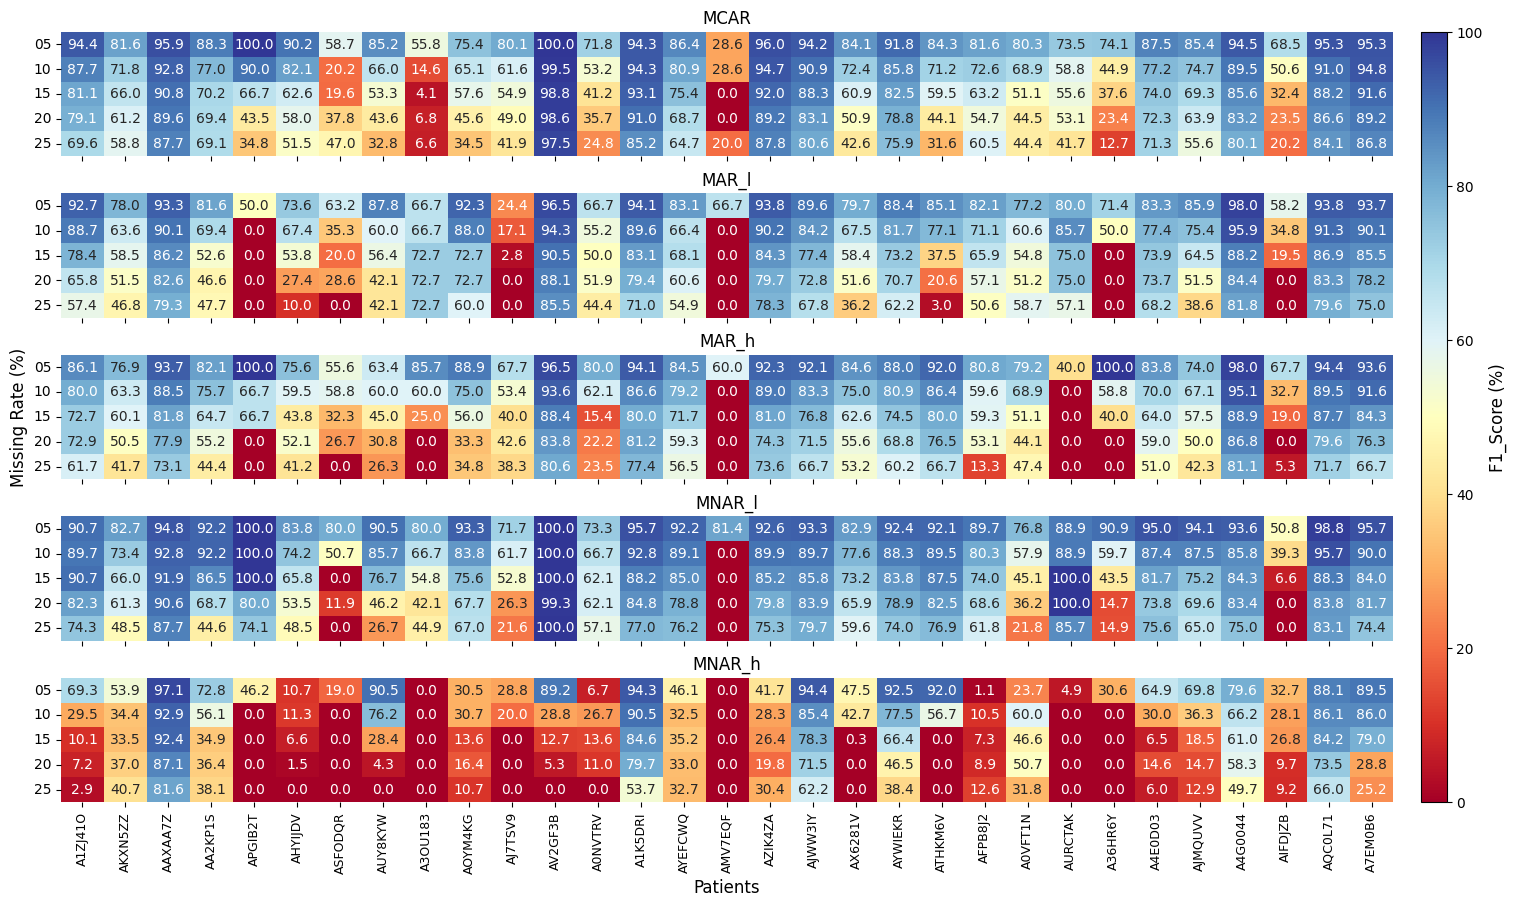

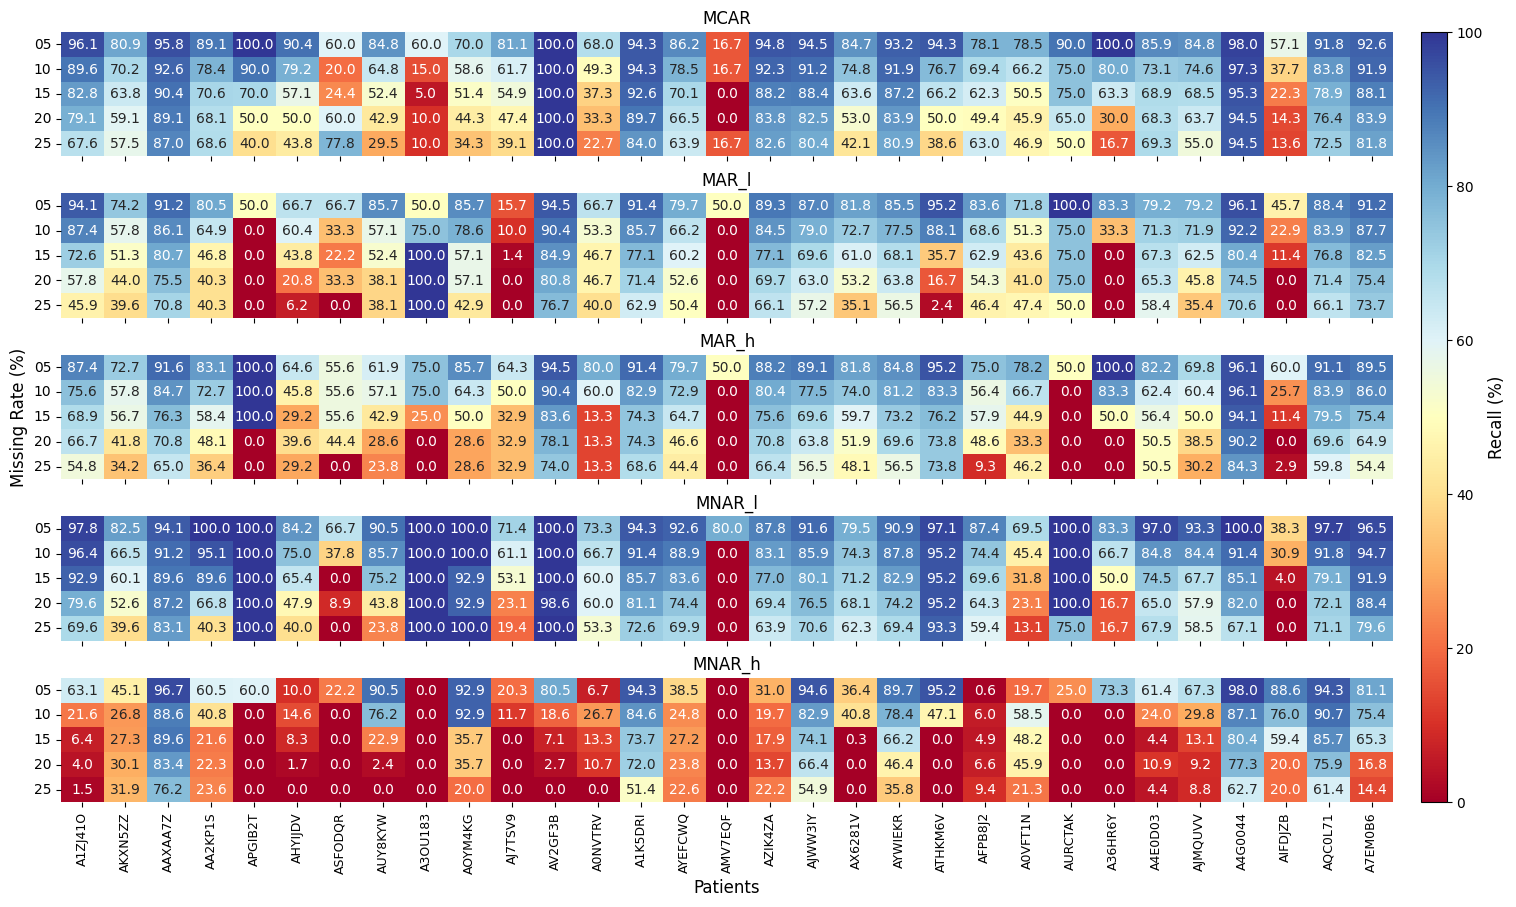

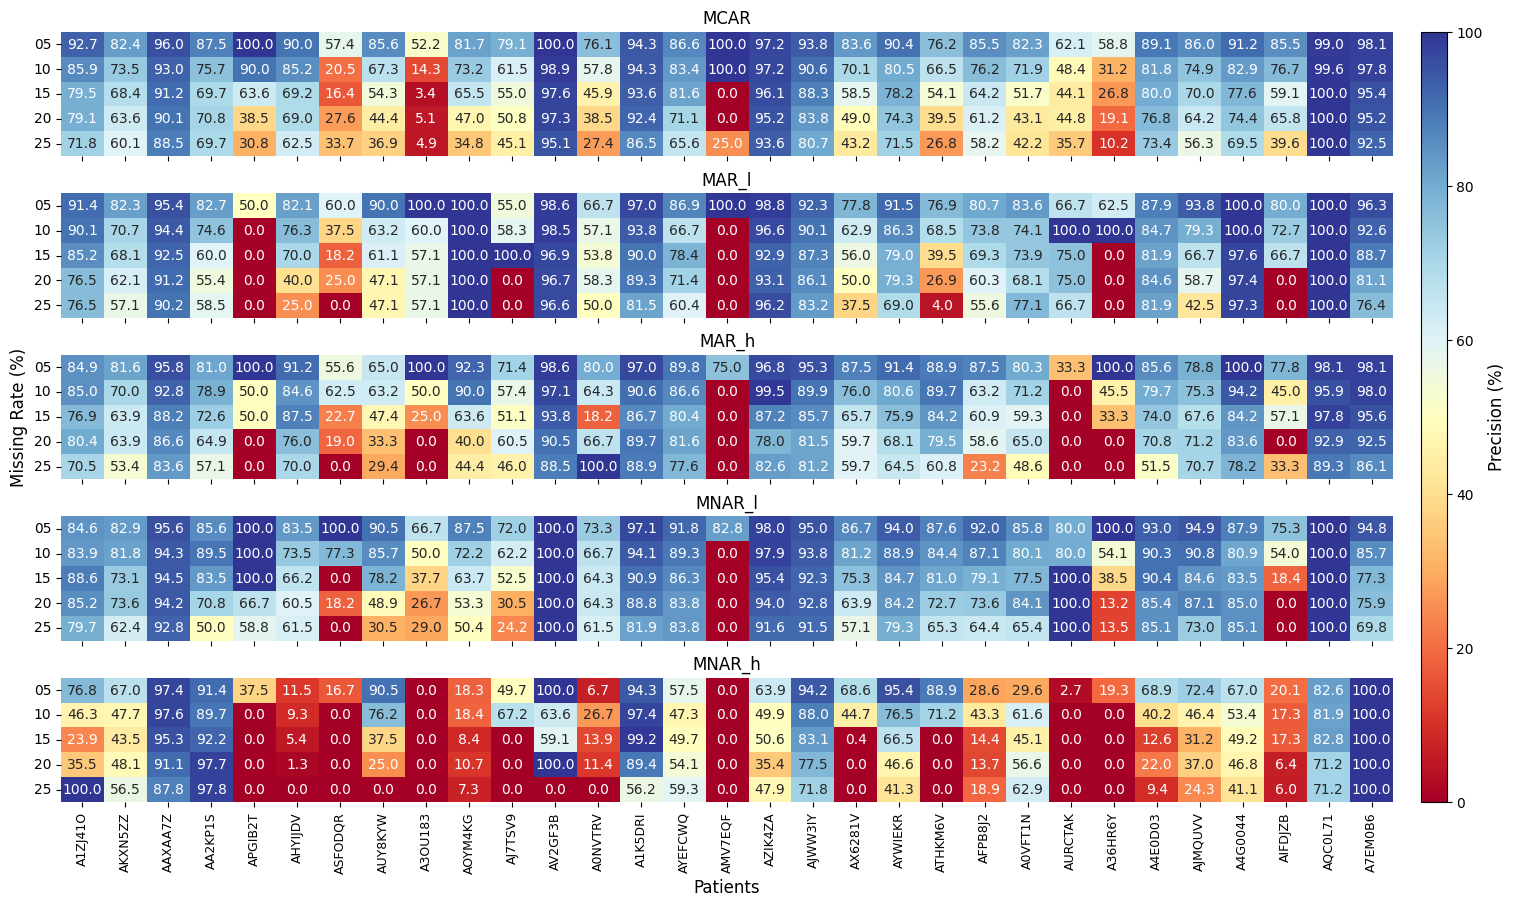

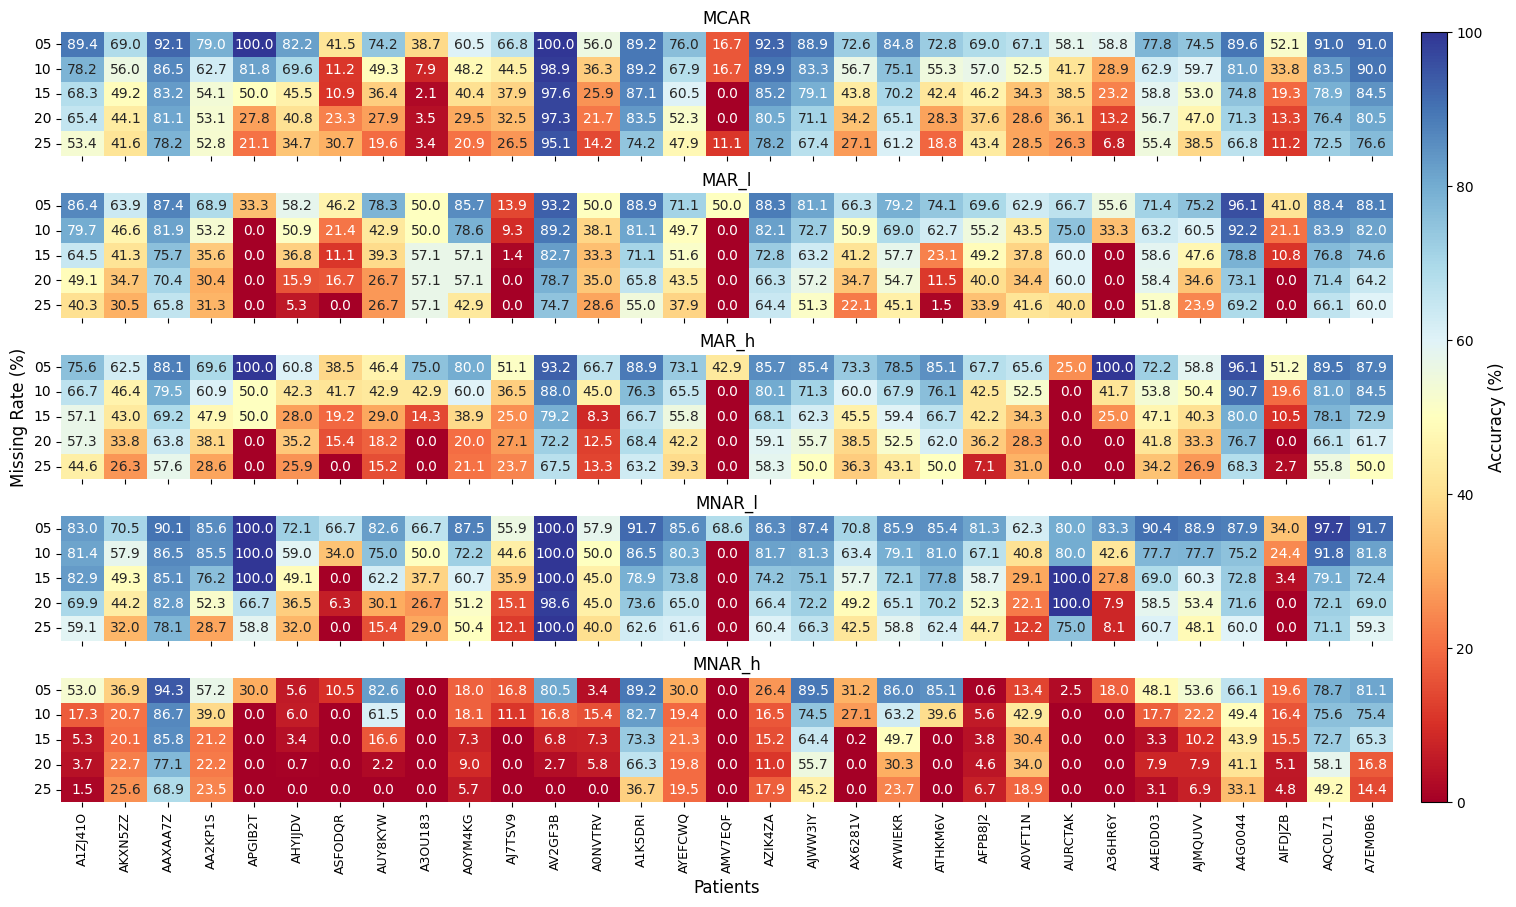

In [ ]:
results_hros.plot_heatmap("F1_Score")
results_hros.plot_heatmap("Recall")
results_hros.plot_heatmap("Precision")
results_hros.plot_heatmap("Accuracy")

In [72]:
results_hros.plot_pheatmap()

AttributeError: 'plotter' object has no attribute 'plot_pheatmap'